# Supplementary Figure S4: minority-class AUPRC

**Purpose.** Evaluate model performance with the minority class in each variant-type subgroup treated as the positive class.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/processed/clinvar_benchmark_updated.csv` (the complete scored benchmark; not stored in GitHub).
- **Outputs:** `results/tables/figure_s4_auprc.csv` and `results/figures/figure_s4.svg`.
- **Randomness:** 200 stratified bootstrap replicates per comparison, seed 42.
- **Compute:** CPU; no model inference is performed.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and inspect input


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import average_precision_score
from tqdm import tqdm

pd.set_option("display.max_columns", 80)

DATA_PATH = SCORED_BENCHMARK_PATH

OUT_CSV = TABLE_DIR / "figure_s4_auprc.csv"
OUT_FIGURE = FIGURE_DIR / "figure_s4.svg"

data = pd.read_csv(DATA_PATH, low_memory=False)


## 3. Compute minority-class AUPRC


In [3]:
# Models, subgroups, and conventions are shared with VEP_AUROC_figure.ipynb.

# Protein models split into two tiers:
#   esm_models        : ESM1b, ESM1v, ESM2, VESM++ (applicable to missense, stop gain, start loss, and combinations)
#   specialist_models  : AlphaMissense, PrimateAI-3D (applicable to missense, stop gain, and combinations, but not start loss)
esm_models     = ["ESM1b", "ESM1v", "ESM2", "vesm_score"]
specialist_models = ["AlphaMissense", "PrimateAI_3D"]
protein_models = esm_models + specialist_models

tools = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr", #"ntv3_pre_seq_pllr",
    #"ntv3_post_position_llr", "ntv3_post_seq_pllr",
    "ntv3_post_log2fc_max",
    "ESM1b", "ESM1v", "ESM2", "vesm_score",
    "AlphaMissense", "PrimateAI_3D",
]

NO_FLIP = {
    "PhyloP", "DNABERT2",
    "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
    "ntv3_post_log2fc_max",
}

# Index boundaries (0-based):
#   DNA-only  : tools[:13]  (indices 0–12, up to ntv3_post_log2fc_max)
#   + ESM     : tools[:17]  (indices 0–16, adds ESM1b/ESM1v/ESM2/vesm_score)
#   + all PLM : tools[:]    (indices 0–19, adds AlphaMissense/PrimateAI_3D)
_DNA   = tools[:11]
_ESM   = tools[:15]
_ALL   = tools[:]

subgroups = [
    "group: missense",                      # 0 — all models
    "group: missense + 3'UTR",               # 1 — all models
    "group: missense + intron (non-splice)", # 2 — all models
    "group: stop gain",                     # 3 — all models
    "group: start loss",                    # 4 — DNA + ESM only (no AlphaMissense/PrimateAI-3D)
    "group: noncoding",                     # 5 — DNA only
    "group: stop loss",                     # 6 — DNA only
    "group: synonymous",                    # 7 — DNA only
    "group: 5'UTR",                          # 8 — DNA only
    "group: 3'UTR",                          # 9 — DNA only
    "group: 3'UTR + RNA gene",               # 10 — DNA only
    "group: splice",                        # 11 — DNA only
    "group: intron (non-splice)",            # 12 — DNA only
    "group: RNA gene",                      # 13 — DNA only
]

TOOLS_PER_SUBGROUP = {}
for i, sg in enumerate(subgroups):
    if i in (0, 1, 2, 3):
        TOOLS_PER_SUBGROUP[sg] = _ALL       # missense, stop gain, combinations — all models
    elif i == 4:
        TOOLS_PER_SUBGROUP[sg] = _ESM       # start loss — DNA + ESM (no AlphaMissense/PrimateAI-3D)
    else:
        TOOLS_PER_SUBGROUP[sg] = _DNA       # noncoding subgroups — DNA only

rename_dict = {
    "Evo2_7B":               "Evo2 7B",
    "Evo2_40B":              "Evo2 40B",
    "DNABERT2":              "DNABERT2",
    "PhyloP":                "PhyloP",
    "AlphaGenome_quantile":  "AlphaGenome",
    "GPN_MSA":               "GPN-MSA",
    "PhyloGPN":              "PhyloGPN",
    "gpnstar_v_llr":         "GPN-Star",
    "ntv3_pre_position_llr": "NTv3-pre",
    "ntv3_pre_seq_pllr":     "NTv3-pre PLLR",
    "ntv3_post_position_llr":"NTv3-post LLR",
    "ntv3_post_seq_pllr":    "NTv3-post PLLR",
    "ntv3_post_log2fc_max":  "NTv3-post",
    "ESM1b":                 "ESM1b",
    "ESM1v":                 "ESM1v",
    "ESM2":                  "ESM2",
    "vesm_score":            "VESM++",
    "PrimateAI_3D":          "PrimateAI-3D",
    "AlphaMissense":         "AlphaMissense",
    "Rule_based":            "Rule-based",
}
palette = {
    "Evo2 7B":          "#e56b6f",
    "Evo2 40B":         "#c93735",
    "DNABERT2":         "#1b78b2",
    "NTv3-pre":     "#6baed6",
    "NTv3-pre PLLR":    "#4292c6",
    "NTv3-post LLR":    "#2171b5",
    "NTv3-post PLLR":   "#084594",
    "NTv3-post": "#54278f",
    "GPN-Star":         "#20b2aa",
    "PhyloP":           "#808080",
    "GPN-MSA":          "#859ed7",
    "PhyloGPN":         "#f47f1e",
    "AlphaGenome":      "#a2d94d",
    "ESM1b":            "#2da248",
    "ESM1v":            "#8f69c5",
    "ESM2":             "#22bdd2",
    "VESM++":           "#e377c2",
    "PrimateAI-3D":     "#d26101",
    "AlphaMissense":    "#333a8c",
    "Rule-based":       "#b0b0b0",
}
dashed_models = ["ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D", "VESM++"]
display_map = {
    "group: noncoding":                      "Noncoding",
    "group: intron (non-splice)":            "Intron (Non-splice)",
    "group: splice":                         "Splice",
    "group: 5'UTR":                          "5' UTR",
    "group: 3'UTR":                          "3' UTR",
    "group: 3'UTR + RNA gene":               "3' UTR + RNA gene",
    "group: RNA gene":                       "RNA gene",
    "group: synonymous":                     "Synonymous",
    "group: start loss":                     "Start loss",
    "group: stop loss":                      "Stop loss",
    "group: missense":                       "Missense",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: missense + 3'UTR":              "Missense & 3'UTR",
    "group: stop gain":                      "Stop gain",
}
ordered_display_names = [
    "All variants", "5' UTR", "Missense",
    "Noncoding", "RNA gene", "Missense & Intron (Non-splice)",
    "Intron (Non-splice)", "Synonymous", "Missense & 3'UTR",
    "Splice", "Stop loss", "Stop gain",
    "3' UTR", "Start loss",
]
# Convenience groupings (display names) for downstream use
DNA_MODELS = [
    "PhyloP", "AlphaGenome", "Evo2 7B", "Evo2 40B", "GPN-MSA",
    "PhyloGPN", "GPN-Star", "NTv3-pre LLR", "NTv3-pre PLLR",
    "NTv3-post LLR", "NTv3-post PLLR", "NTv3-post log2FC", "DNABERT2",
]
ESM_MODELS     = ["ESM1b", "ESM1v", "ESM2", "VESM++"]
PROTEIN_MODELS = ESM_MODELS + ["AlphaMissense", "PrimateAI-3D"]


In [4]:
# Bootstrap AUPRC helper.
# AUPRC is computed on the *minority* class (pathogenic or benign): in groups
# dominated by pathogenic labels we flip labels so y=1 identifies the rare
# class, and negate scores so "higher = more likely positive" for PR.
# Chance-level AUPRC equals the prevalence of that AUPRC positive class.

MIN_PER_CLASS = 5


def auprc_chance_level_and_positive_class(y_pathogenic):
    """Baseline (random ranker) AUPRC and name of the AUPRC positive class."""
    y_pathogenic = np.asarray(y_pathogenic).astype(int)
    n = len(y_pathogenic)
    if n == 0:
        return np.nan, ""
    n_pos = int(y_pathogenic.sum())
    n_neg = n - n_pos
    if n_pos > n_neg:
        return float(n_neg) / n, "benign"
    return float(n_pos) / n, "pathogenic"


def prepare_auprc_inputs(y_pathogenic, scores_pathogenic_high):
    """Return (y_auprc, s_auprc, baseline, positive_class) for average_precision_score."""
    y_pathogenic = np.asarray(y_pathogenic).astype(int)
    scores_pathogenic_high = np.asarray(scores_pathogenic_high).astype(float)
    n = len(y_pathogenic)
    if n == 0:
        return np.array([]), np.array([]), np.nan, ""
    n_pos = int(y_pathogenic.sum())
    n_neg = n - n_pos
    if n_pos > n_neg:
        y_ap = 1 - y_pathogenic
        s_ap = -scores_pathogenic_high
        baseline = float(n_neg) / n
        positive_class = "benign"
    else:
        y_ap = y_pathogenic
        s_ap = scores_pathogenic_high
        baseline = float(n_pos) / n
        positive_class = "pathogenic"
    return y_ap, s_ap, baseline, positive_class


N_BOOTSTRAPS = 200


def bootstrap_auprc_ci(y, s, n_boot=N_BOOTSTRAPS, seed=42):
    y = np.asarray(y).astype(int)
    s = np.asarray(s).astype(float)
    n = len(y)
    if n == 0 or len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan
    ap_hat = average_precision_score(y, s)
    rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(y == label) for label in (0, 1)]
    aps = []
    for _ in range(n_boot):
        idx = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in class_indices
        ])
        aps.append(average_precision_score(y[idx], s[idx]))
    if len(aps) < max(30, 0.5 * n_boot):
        return float(ap_hat), np.nan, np.nan
    lo, hi = np.percentile(aps, [2.5, 97.5])
    return float(ap_hat), float(lo), float(hi)


In [5]:
# Compute AUPRC and prevalence per (subgroup, model).
# `prevalence` = chance-level AUPRC (minority-class prevalence).
# `prevalence_pathogenic` = fraction ClinVar-pathogenic (1) in the subgroup.

rows = []

# Overall (all variants): DNA-only tools (indices 0–12); protein models not included in the overall panel.
overall_tools = _DNA
overall_sub = data[data[overall_tools[:7]].notna().all(axis=1)].copy()
y_overall = overall_sub["ClinVar_label"].astype(int).values
prev_path_overall = float(y_overall.mean()) if len(y_overall) else np.nan
baseline_overall, pos_cls_overall = auprc_chance_level_and_positive_class(y_overall)

for tool in tools:
    tool_disp = rename_dict[tool]
    if tool in overall_tools:
        scores = overall_sub[tool].values.astype(float)
        if tool not in NO_FLIP:
            scores = -scores
        y_ap, s_ap, _, _ = prepare_auprc_inputs(y_overall, scores)
        ap, lo, hi = bootstrap_auprc_ci(y_ap, s_ap)
    else:
        ap, lo, hi = (np.nan, np.nan, np.nan)
    rows.append({
        "subgroup_raw": "Overall",
        "subgroup_display": "All variants",
        "model": tool_disp,
        "N": len(overall_sub), "N_pos": int(y_overall.sum()),
        "N_neg": int(len(overall_sub) - y_overall.sum()),
        "prevalence_pathogenic": prev_path_overall,
        "prevalence": baseline_overall,
        "auprc_positive_class": pos_cls_overall,
        "AUPRC": ap, "CI_low": lo, "CI_high": hi,
        "AUPRC_minus_baseline": (ap - baseline_overall) if not np.isnan(ap) else np.nan,
    })

for sg, sg_tools in tqdm(list(TOOLS_PER_SUBGROUP.items()), desc="Subgroups"):
    sg_df = data[data[sg] == 1]
    sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
    y = sg_df["ClinVar_label"].astype(int).values
    n = len(sg_df)
    npos = int(y.sum()); nneg = n - npos
    prev_path = float(npos / n) if n else np.nan
    baseline_sg, pos_cls_sg = auprc_chance_level_and_positive_class(y)
    disp = display_map.get(sg, sg)
    for tool in tools:
        tool_disp = rename_dict[tool]
        if tool not in sg_tools:
            ap, lo, hi = (np.nan, np.nan, np.nan)
        elif npos < MIN_PER_CLASS or nneg < MIN_PER_CLASS:
            ap, lo, hi = (np.nan, np.nan, np.nan)
        else:
            scores = sg_df[tool].values.astype(float)
            if tool not in NO_FLIP:
                scores = -scores
            y_ap, s_ap, _, _ = prepare_auprc_inputs(y, scores)
            ap, lo, hi = bootstrap_auprc_ci(y_ap, s_ap)
        rows.append({
            "subgroup_raw": sg, "subgroup_display": disp, "model": tool_disp,
            "N": n, "N_pos": npos, "N_neg": nneg,
            "prevalence_pathogenic": prev_path,
            "prevalence": baseline_sg,
            "auprc_positive_class": pos_cls_sg,
            "AUPRC": ap, "CI_low": lo, "CI_high": hi,
            "AUPRC_minus_baseline": (ap - baseline_sg) if not np.isnan(ap) else np.nan,
        })

auprc_df = pd.DataFrame(rows)
auprc_df.to_csv(OUT_CSV, index=False)
print(f"Saved full AUPRC table: {OUT_CSV.relative_to(REPO_ROOT)}  ({len(auprc_df):,} rows)")


Subgroups:   0%|          | 0/14 [00:00<?, ?it/s]

Subgroups:   7%|▋         | 1/14 [00:16<03:40, 16.98s/it]

Subgroups:  14%|█▍        | 2/14 [00:18<01:31,  7.65s/it]

Subgroups:  21%|██▏       | 3/14 [00:19<00:51,  4.69s/it]

Subgroups:  29%|██▊       | 4/14 [00:35<01:34,  9.45s/it]

...

Subgroups:  86%|████████▌ | 12/14 [01:29<00:08,  4.23s/it]

Subgroups:  93%|█████████▎| 13/14 [01:54<00:09,  9.43s/it]

Subgroups: 100%|██████████| 14/14 [01:55<00:00,  7.14s/it]

Subgroups: 100%|██████████| 14/14 [01:55<00:00,  8.26s/it]

Saved full AUPRC table: results/tables/figure_s4_auprc.csv  (255 rows)


## 4. Render the manuscript figure


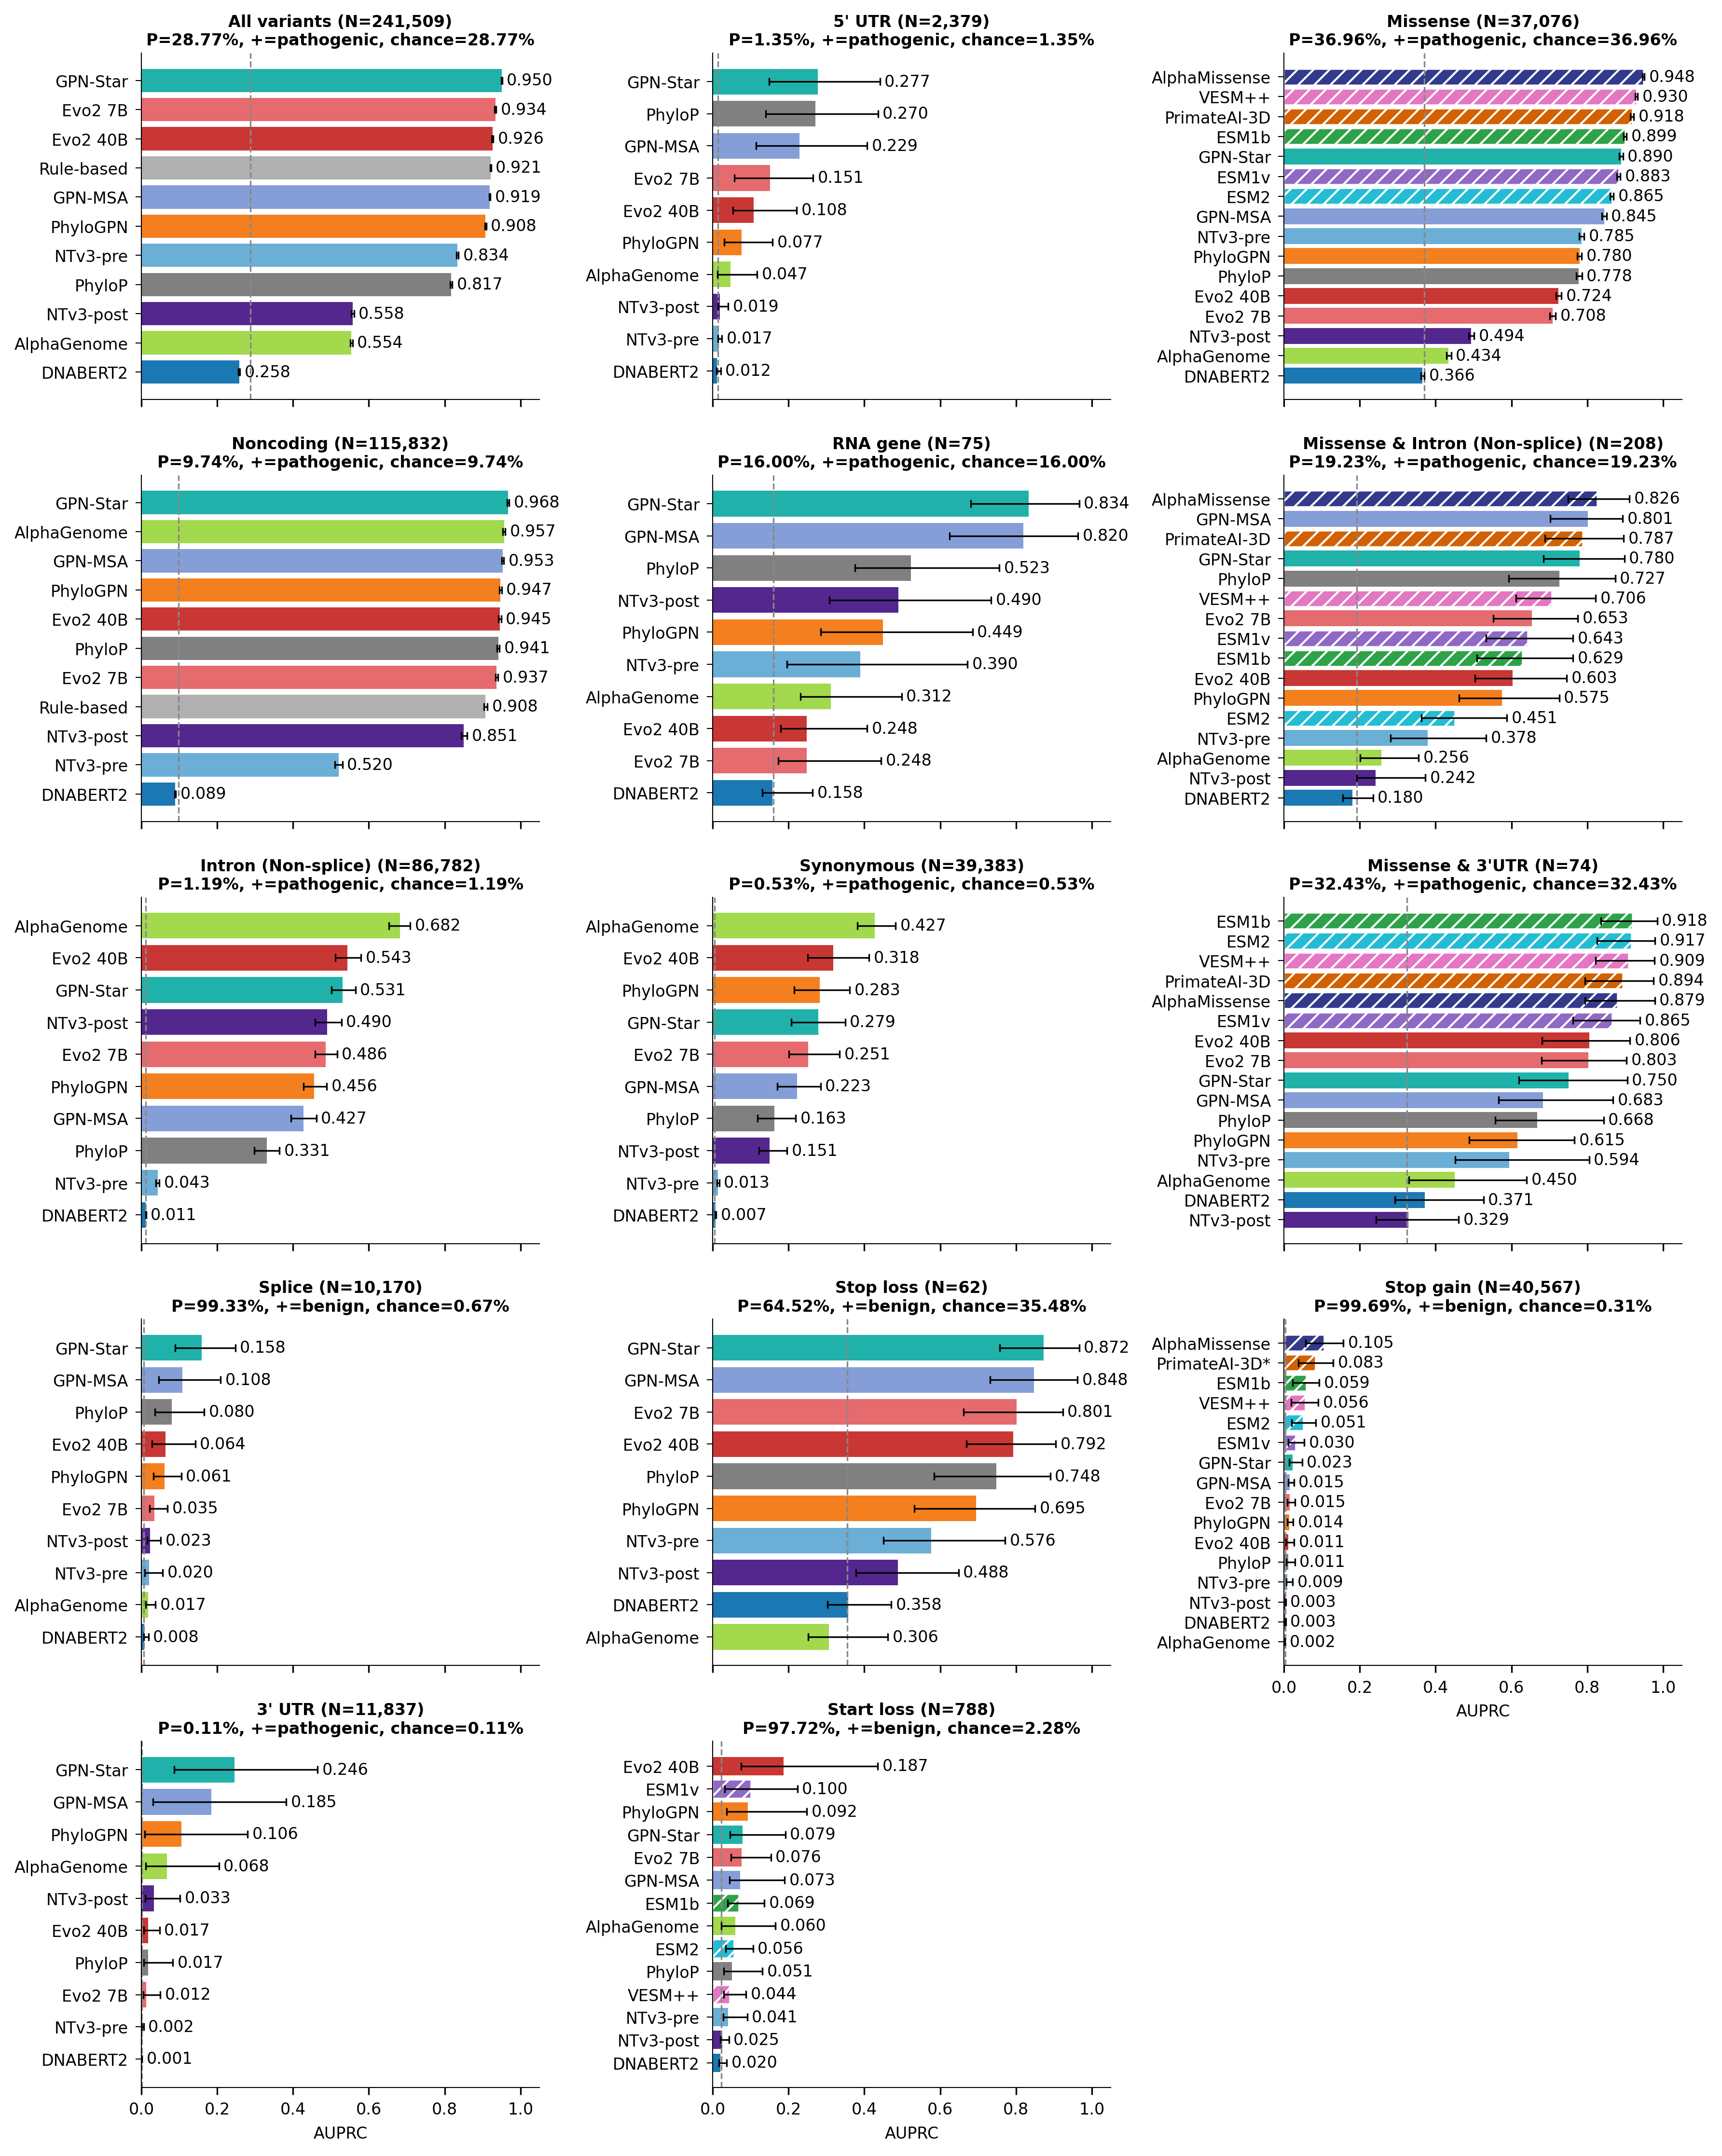

In [2]:
# Supplementary Figure S4 mirrors the Figure 1 panel order and labels
# every bar with its actual AUPRC value.

FONT_SIZE = 8
FONT_NAME = "DejaVu Sans"


def draw_panel(ax, display_name, show_xlabel=False, show_numbers=False):
    panel = auprc_df[
        (auprc_df["subgroup_display"] == display_name) & auprc_df["AUPRC"].notna()
    ].copy()
    if display_name not in ("All variants", "Noncoding"):
        panel = panel[panel["model"] != "Rule-based"]
    panel = panel.sort_values("AUPRC", ascending=True)

    n = int(panel["N"].iloc[0]) if len(panel) else 0
    prevalence = float(panel["prevalence"].iloc[0]) if len(panel) else np.nan
    pathogenic_prevalence = float(panel["prevalence_pathogenic"].iloc[0]) if len(panel) else np.nan
    positive_class = str(panel["auprc_positive_class"].iloc[0]) if len(panel) else ""

    for _, row in panel.iterrows():
        color = palette.get(row["model"], "#444444")
        hatch = "///" if row["model"] in dashed_models else None
        label = row["model"]
        if display_name == "Stop gain" and row["model"] == "PrimateAI-3D":
            label = "PrimateAI-3D*"
        ax.barh(
            label, row["AUPRC"], color=color, hatch=hatch,
            edgecolor="white" if hatch else None, linewidth=0.6,
        )

        low, high = row["CI_low"], row["CI_high"]
        if pd.notna(low) and pd.notna(high) and high >= low:
            ax.errorbar(
                row["AUPRC"], label,
                xerr=[[row["AUPRC"] - low], [high - row["AUPRC"]]],
                fmt="none", ecolor="black", elinewidth=0.8,
                capsize=2, capthick=0.8, zorder=10,
            )
            anchor = max(row["AUPRC"], high)
        else:
            anchor = row["AUPRC"]
        ax.text(
            min(anchor + 0.012, 1.02), label, f"{row['AUPRC']:.3f}",
            va="center", ha="left", fontsize=FONT_SIZE, fontname=FONT_NAME,
        )

    if not np.isnan(prevalence):
        ax.axvline(prevalence, color="#888888", lw=0.8, ls="--")

    ax.set_xlim(0, 1.05)
    ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_xticks(ticks)
    if show_numbers:
        ax.set_xticklabels([f"{tick:.1f}" for tick in ticks], fontsize=FONT_SIZE)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    if show_xlabel:
        ax.set_xlabel("AUPRC", fontsize=FONT_SIZE, fontname=FONT_NAME)

    ax.tick_params(axis="y", which="major", left=True, labelleft=True, width=0.5, length=3.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(labelsize=FONT_SIZE)
    for label in ax.get_yticklabels():
        label.set_fontname(FONT_NAME)

    pathogenic_text = f"{100 * pathogenic_prevalence:.2f}%" if not np.isnan(pathogenic_prevalence) else "NA"
    chance_text = f"{100 * prevalence:.2f}%" if not np.isnan(prevalence) else "NA"
    ax.set_title(
        f"{display_name} (N={n:,})\n"
        f"P={pathogenic_text}, +={positive_class}, chance={chance_text}",
        fontsize=FONT_SIZE, fontname=FONT_NAME, fontweight="bold", pad=4,
    )


fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 15), dpi=300)
axes = axes.flatten()
last_panel_by_column = {
    column: max(i for i in range(len(ordered_display_names)) if i % 3 == column)
    for column in range(3)
}
for i, display_name in enumerate(ordered_display_names):
    show_x = i == last_panel_by_column[i % 3]
    draw_panel(axes[i], display_name, show_xlabel=show_x, show_numbers=show_x)
for axis in axes[len(ordered_display_names):]:
    axis.axis("off")

fig.tight_layout()
fig.savefig(OUT_FIGURE, format="svg", bbox_inches="tight")
plt.show()


## Interpretation

The dashed line in each panel is the minority-class prevalence and therefore the chance-level AUPRC for that subgroup. Each bar is labeled with the actual AUPRC value. Because the positive class and its prevalence differ among variant types, we interpret AUPRC within each panel rather than comparing its absolute magnitude across panels.


## 5. Validate outputs


In [7]:
validate_output_files([
    TABLE_DIR / "figure_s4_auprc.csv",
    FIGURE_DIR / "figure_s4.svg",
])


Validated 2 output file(s).
